# Face Skin Detection — Training Pipeline
**Notebook ini mencakup:**
1. Setup & Load Dataset
2. EDA (Exploratory Data Analysis)
3. Preprocessing & Feature Extraction
4. Training Model (Naive Bayes, SVM, Logistic Regression)
5. Evaluasi & Perbandingan Model
6. Evaluasi Severity Score (Regresi)
7. Export Model Terbaik

---
> **Dataset:** [Facial Skin: Acne, Pigmentation, Pores, Wrinkles](https://www.kaggle.com/datasets/shijo96john/facial-skin-acne-pigmentation-pores-wrinkles)  
> Letakkan dataset di folder: `../data/raw/`

## 0. Install Dependencies

In [1]:
# Jalankan cell ini sekali untuk install semua library
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', 'scikit-image', 'opencv-python',
                'matplotlib', 'seaborn', 'pandas', 'numpy', 'Pillow', 'joblib',
                'imbalanced-learn', 'tqdm'], check=True)
print('Semua library berhasil diinstall!')

Semua library berhasil diinstall!


## 1. Setup & Load Dataset

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import joblib

from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import Counter

from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ============================================================
# KONFIGURASI — sesuaikan jika nama folder dataset berbeda
# ============================================================
DATASET_PATH  = Path('../data/raw')   # folder berisi subfolder per class
MODELS_PATH   = Path('../models')
IMG_SIZE      = (128, 128)            # resize target
TEST_SIZE     = 0.2
RANDOM_STATE  = 42

MODELS_PATH.mkdir(parents=True, exist_ok=True)

print('Setup selesai.')
print(f'Dataset path : {DATASET_PATH.resolve()}')
print(f'Models path  : {MODELS_PATH.resolve()}')

Setup selesai.
Dataset path : D:\AKADEMIK\SEMESTER 4\ML\face detection\face-skin-detection\backend-ml\data\raw
Models path  : D:\AKADEMIK\SEMESTER 4\ML\face detection\face-skin-detection\backend-ml\models


In [3]:
# Deteksi class dari nama folder di dalam DATASET_PATH
class_dirs = sorted([d for d in DATASET_PATH.iterdir() if d.is_dir()])

if not class_dirs:
    raise FileNotFoundError(
        f'Tidak ada subfolder ditemukan di {DATASET_PATH.resolve()}\n'
        'Pastikan dataset sudah di-extract ke folder data/raw/'
    )

CLASS_NAMES = [d.name for d in class_dirs]
print(f'Class yang ditemukan ({len(CLASS_NAMES)}): {CLASS_NAMES}')

Class yang ditemukan (8): ['dark spots', 'inflammatory acne', 'non inflammatory acne black heads', 'non inflammatory acne white heads', 'pigmentation', 'pores', 'Redness', 'wrinkles']


In [4]:
# Severity score mapping — sesuaikan dengan class_names aktual
# Tambah/hapus entry jika nama folder dataset berbeda
SEVERITY_MAP = {
    'dark spots'                        : 70,
    'inflammatory acne'                 : 80,
    'non inflammatory acne black heads' : 65,
    'non inflammatory acne white heads' : 60,
    'pigmentation'                      : 50,
    'pores'                             : 35,
    'Redness'                           : 75,
    'wrinkles'                          : 60,
}

def get_severity(class_name: str) -> int:
    """Ambil severity score; default 50 jika class tidak terdaftar."""
    return SEVERITY_MAP.get(class_name, 50)

def severity_level(score: int) -> str:
    if score <= 30:
        return 'Mild'
    elif score <= 60:
        return 'Moderate'
    else:
        return 'Severe'

print('Severity map siap.')
for cls in CLASS_NAMES:
    score = get_severity(cls)
    print(f'  {cls:30s} → score={score:3d}  ({severity_level(score)})')

Severity map siap.
  dark spots                     → score= 70  (Severe)
  inflammatory acne              → score= 80  (Severe)
  non inflammatory acne black heads → score= 65  (Severe)
  non inflammatory acne white heads → score= 60  (Moderate)
  pigmentation                   → score= 50  (Moderate)
  pores                          → score= 35  (Moderate)
  Redness                        → score= 75  (Severe)
  wrinkles                       → score= 60  (Moderate)


## 2. EDA — Exploratory Data Analysis

In [5]:
# Hitung jumlah gambar per class dan kumpulkan metadata
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

records = []
corrupt = []

for cls_dir in tqdm(class_dirs, desc='Scanning dataset'):
    for img_path in cls_dir.iterdir():
        if img_path.suffix.lower() not in VALID_EXTS:
            continue
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                mode = img.mode
            records.append({'class': cls_dir.name, 'path': str(img_path),
                             'width': w, 'height': h, 'mode': mode})
        except Exception:
            corrupt.append(str(img_path))

df_meta = pd.DataFrame(records)
print(f'Total gambar valid  : {len(df_meta)}')
print(f'Gambar korup/rusak  : {len(corrupt)}')
print()
print('Distribusi per class:')
print(df_meta['class'].value_counts().to_string())

Scanning dataset: 100%|██████████| 8/8 [00:49<00:00,  6.19s/it]

Total gambar valid  : 4233
Gambar korup/rusak  : 0

Distribusi per class:
class
dark spots                           619
inflammatory acne                    603
pores                                600
Redness                              600
wrinkles                             600
pigmentation                         599
non inflammatory acne black heads    312
non inflammatory acne white heads    300


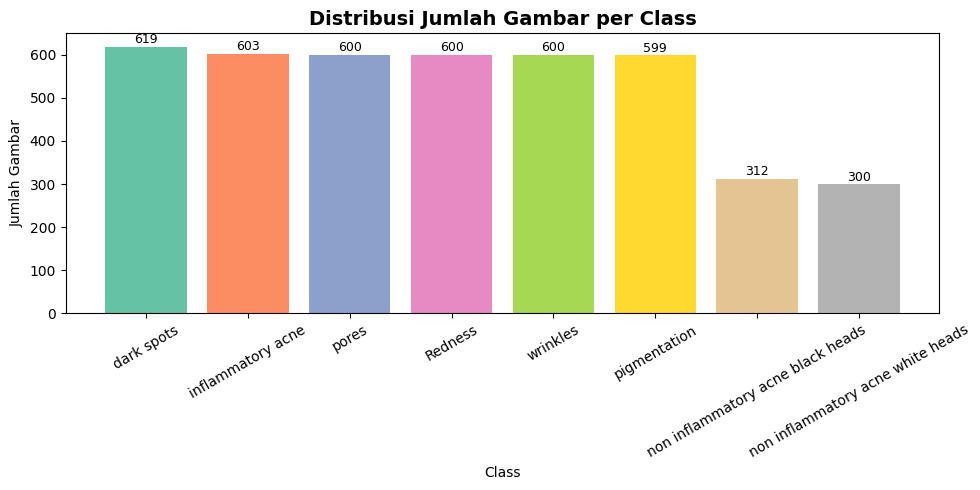

In [6]:
# ── Plot 1: Distribusi jumlah gambar per class ──────────────────────────────
counts = df_meta['class'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color=plt.cm.Set2.colors[:len(counts)])
ax.set_title('Distribusi Jumlah Gambar per Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Jumlah Gambar')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../models/eda_class_distribution.png', dpi=120)
plt.show()

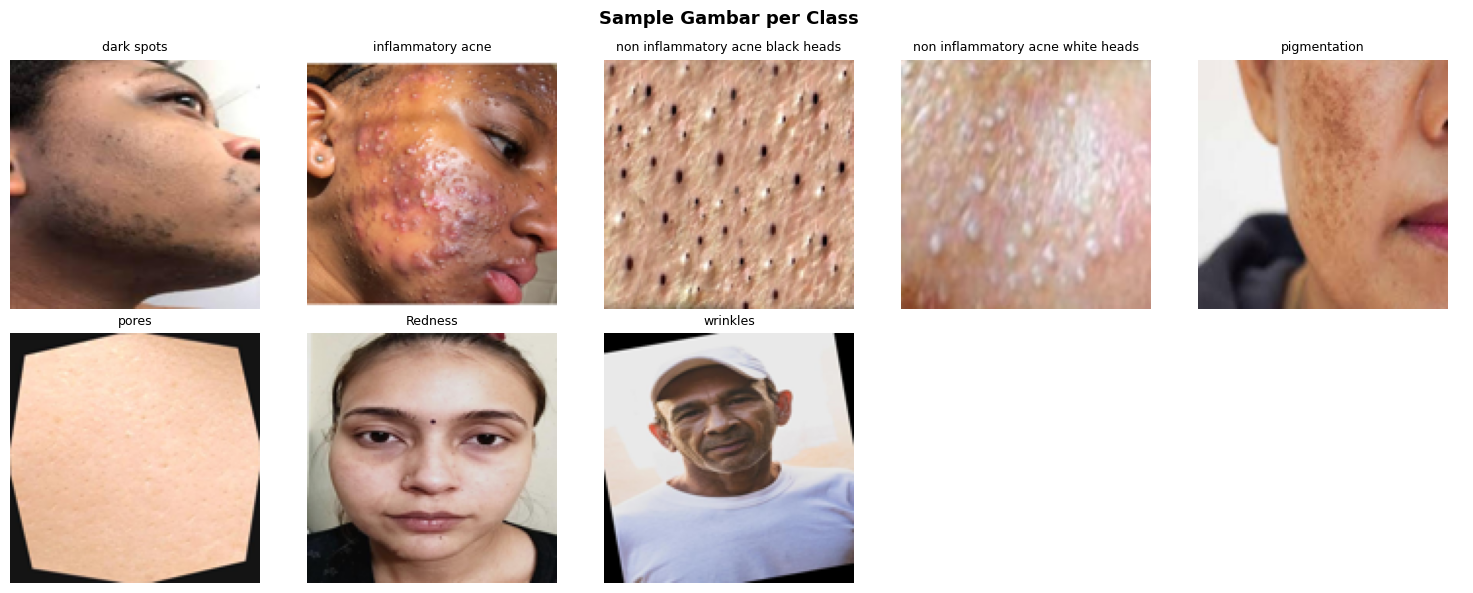

In [7]:
# ── Plot 2: Sample gambar per class ────────────────────────────────────────
n_cols = min(len(CLASS_NAMES), 5)
n_rows = -(-len(CLASS_NAMES) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = np.array(axes).flatten()

for idx, cls in enumerate(CLASS_NAMES):
    sample_paths = df_meta[df_meta['class'] == cls]['path'].values
    if len(sample_paths) == 0:
        axes[idx].axis('off')
        continue
    img = Image.open(sample_paths[0]).convert('RGB').resize((128, 128))
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=9)
    axes[idx].axis('off')

for idx in range(len(CLASS_NAMES), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_sample_images.png', dpi=120)
plt.show()

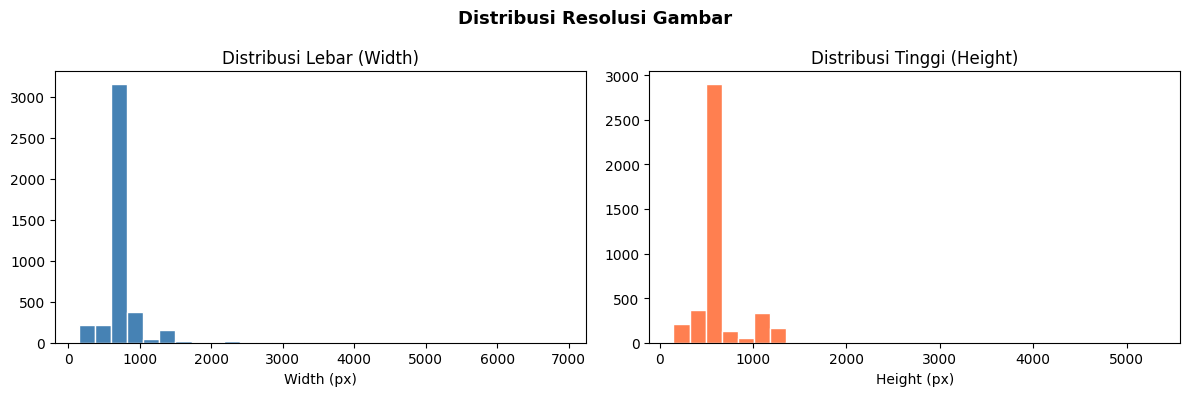

        width  height
count  4233.0  4233.0
mean    710.3   693.8
std     317.4   336.2
min     150.0   149.0
25%     640.0   640.0
50%     640.0   640.0
75%     640.0   640.0
max    6900.0  5312.0


In [8]:
# ── Plot 3: Distribusi resolusi gambar ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_meta['width'],  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Lebar (Width)')
axes[0].set_xlabel('Width (px)')

axes[1].hist(df_meta['height'], bins=30, color='coral',     edgecolor='white')
axes[1].set_title('Distribusi Tinggi (Height)')
axes[1].set_xlabel('Height (px)')

plt.suptitle('Distribusi Resolusi Gambar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_resolution.png', dpi=120)
plt.show()

print(df_meta[['width','height']].describe().round(1))

In [9]:
# ── Cek class imbalance ────────────────────────────────────────────────────
min_count = counts.min()
max_count = counts.max()
ratio = max_count / min_count

print(f'Class terbanyak : {counts.idxmax()} ({max_count} gambar)')
print(f'Class tersedikit: {counts.idxmin()} ({min_count} gambar)')
print(f'Imbalance ratio : {ratio:.2f}x')

if ratio > 3:
    print('\n⚠️  Dataset cukup imbalanced (ratio > 3x). Akan digunakan stratified split.')
else:
    print('\n✅ Dataset relatif balanced.')

Class terbanyak : dark spots (619 gambar)
Class tersedikit: non inflammatory acne white heads (300 gambar)
Imbalance ratio : 2.06x

✅ Dataset relatif balanced.


## 3. Preprocessing & Feature Extraction

In [10]:
def preprocess_image(img_path: str, size: tuple = IMG_SIZE) -> np.ndarray | None:
    """
    Load → resize → convert RGB → normalize ke [0, 1].
    Return None jika file korup.
    """
    try:
        img = Image.open(img_path).convert('RGB').resize(size, Image.LANCZOS)
        return np.array(img, dtype=np.float32) / 255.0
    except Exception:
        return None


def extract_hog_features(img_arr: np.ndarray) -> np.ndarray:
    """
    Ekstrak HOG features dari gambar (nilai 0–1, shape HxWx3).
    Konversi ke grayscale dulu agar HOG lebih stabil.
    """
    gray = np.mean(img_arr, axis=2)           # simple grayscale
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features


def extract_color_histogram(img_arr: np.ndarray, bins: int = 32) -> np.ndarray:
    """
    Ekstrak color histogram untuk tiap channel R, G, B.
    Total fitur = bins × 3.
    """
    hists = []
    for ch in range(3):
        hist, _ = np.histogram(img_arr[:, :, ch], bins=bins, range=(0, 1))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-6)           # normalisasi
        hists.append(hist)
    return np.concatenate(hists)


def extract_features(img_path: str) -> np.ndarray | None:
    """Gabungkan HOG + Color Histogram → satu feature vector."""
    img_arr = preprocess_image(img_path)
    if img_arr is None:
        return None
    hog_feat   = extract_hog_features(img_arr)
    color_feat = extract_color_histogram(img_arr)
    return np.concatenate([hog_feat, color_feat])


print('Fungsi preprocessing & feature extraction siap.')

# Cek dimensi output pada 1 gambar sample
sample_path = df_meta['path'].values[0]
sample_feat = extract_features(sample_path)
print(f'Dimensi feature vector  : {sample_feat.shape[0]}')
print(f'  HOG   : {extract_hog_features(preprocess_image(sample_path)).shape[0]}')
print(f'  Color : {extract_color_histogram(preprocess_image(sample_path)).shape[0]}')

Fungsi preprocessing & feature extraction siap.
Dimensi feature vector  : 1860
  HOG   : 1764
  Color : 96


In [11]:
# Ekstrak semua fitur dari dataset
# ⏳ Proses ini membutuhkan beberapa menit tergantung ukuran dataset

X_list, y_list, paths_ok = [], [], []

for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Extracting features'):
    feat = extract_features(row['path'])
    if feat is not None:
        X_list.append(feat)
        y_list.append(row['class'])
        paths_ok.append(row['path'])

X_raw = np.array(X_list, dtype=np.float32)
y_raw = np.array(y_list)

print(f'\nFeature matrix shape : {X_raw.shape}')
print(f'Label array shape    : {y_raw.shape}')

Extracting features: 100%|██████████| 4233/4233 [00:39<00:00, 106.97it/s]


Feature matrix shape : (4233, 1860)
Label array shape    : (4233,)


In [12]:
# Label encoding & scaling
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print('Classes setelah encoding:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx} → {cls}')

Classes setelah encoding:
  0 → Redness
  1 → dark spots
  2 → inflammatory acne
  3 → non inflammatory acne black heads
  4 → non inflammatory acne white heads
  5 → pigmentation
  6 → pores
  7 → wrinkles


In [13]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc,
    test_size=TEST_SIZE,
    stratify=y_enc,
    random_state=RANDOM_STATE
)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')

# Distribusi class di test set
test_dist = pd.Series(le.inverse_transform(y_test)).value_counts()
print('\nDistribusi class di test set:')
print(test_dist.to_string())

Train set : 3386 samples
Test set  : 847 samples

Distribusi class di test set:
dark spots                           124
inflammatory acne                    121
Redness                              120
pigmentation                         120
wrinkles                             120
pores                                120
non inflammatory acne black heads     62
non inflammatory acne white heads     60


## 4. Training Model

In [15]:
# Definisi model
models = {
    'Naive Bayes'         : GaussianNB(),
    'SVM'                 : SVC(kernel='rbf', C=10, gamma='scale',
                                probability=True, random_state=RANDOM_STATE),
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0,
                                               solver='lbfgs',
                                               random_state=RANDOM_STATE),
}

print('Model yang akan dilatih:')
for name, model in models.items():
    print(f'  • {name}: {model}')

Model yang akan dilatih:
  • Naive Bayes: GaussianNB()
  • SVM: SVC(C=10, probability=True, random_state=42)
  • Logistic Regression: LogisticRegression(max_iter=1000, random_state=42)


In [16]:
# Training semua model
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    trained_models[name] = model
    print('selesai ✅')

print('\nSemua model berhasil dilatih!')

Training Naive Bayes... selesai ✅
Training SVM... selesai ✅
Training Logistic Regression... selesai ✅

Semua model berhasil dilatih!


## 5. Evaluasi & Perbandingan Model (Klasifikasi)

In [17]:
# Hitung metrik untuk semua model
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro' : f1_score(y_test, y_pred, average='macro', zero_division=0),
    }

# Tabel perbandingan
df_results = pd.DataFrame([
    {'Model': name, 'Accuracy': v['accuracy'], 'Precision': v['precision'],
     'Recall': v['recall'], 'F1-Score (macro)': v['f1_macro']}
    for name, v in results.items()
]).sort_values('F1-Score (macro)', ascending=False)

print('=== Perbandingan Model ===')
print(df_results.to_string(index=False, float_format='{:.4f}'.format))

=== Perbandingan Model ===
              Model  Accuracy  Precision  Recall  F1-Score (macro)
                SVM    0.7096     0.7055  0.6914            0.6962
Logistic Regression    0.5915     0.5753  0.5769            0.5747
        Naive Bayes    0.4510     0.4549  0.4365            0.4244


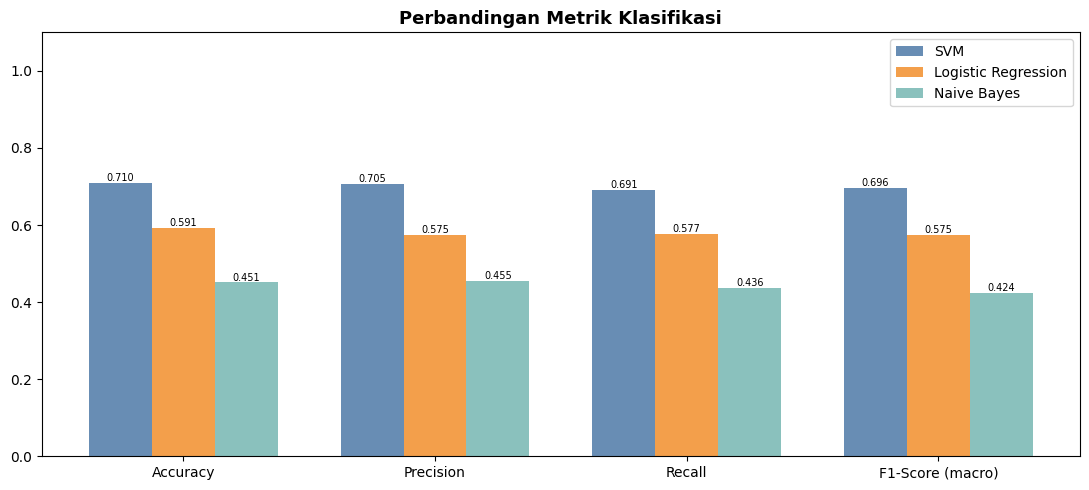

In [18]:
# ── Plot bar chart perbandingan metrik ─────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score (macro)']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4e79a7', '#f28e2b', '#76b7b2']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, row) in enumerate(df_results.iterrows()):
    vals = [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score (macro)']]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=row['Model'], color=colors[i], alpha=0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan Metrik Klasifikasi', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/eval_model_comparison.png', dpi=120)
plt.show()

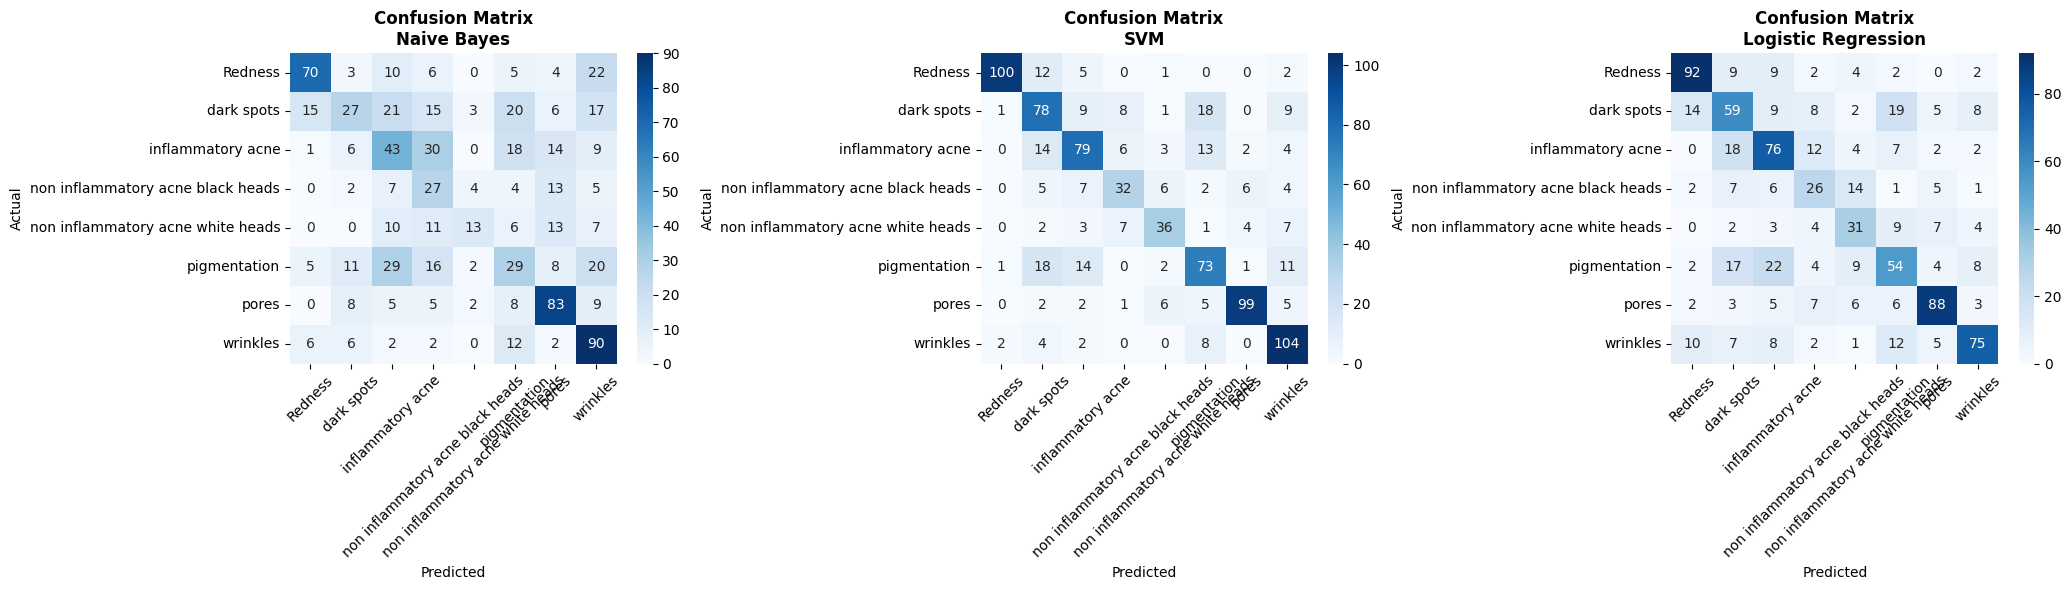

In [19]:
# ── Confusion Matrix untuk semua model ────────────────────────────────────
fig, axes = plt.subplots(1, len(trained_models), figsize=(7 * len(trained_models), 6))
if len(trained_models) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_
    )
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../models/eval_confusion_matrices.png', dpi=120)
plt.show()

In [20]:
# ── Classification Report per model ───────────────────────────────────────
for name, res in results.items():
    print(f'\n{'='*60}')
    print(f' Classification Report — {name}')
    print('='*60)
    print(classification_report(y_test, res['y_pred'],
                                 target_names=le.classes_, zero_division=0))


 Classification Report — Naive Bayes
                                   precision    recall  f1-score   support

                          Redness       0.72      0.58      0.65       120
                       dark spots       0.43      0.22      0.29       124
                inflammatory acne       0.34      0.36      0.35       121
non inflammatory acne black heads       0.24      0.44      0.31        62
non inflammatory acne white heads       0.54      0.22      0.31        60
                     pigmentation       0.28      0.24      0.26       120
                            pores       0.58      0.69      0.63       120
                         wrinkles       0.50      0.75      0.60       120

                         accuracy                           0.45       847
                        macro avg       0.45      0.44      0.42       847
                     weighted avg       0.46      0.45      0.44       847


 Classification Report — SVM
                             

## 6. Evaluasi Severity Score (Regresi)

In [21]:
# Buat array severity score berdasarkan label class
y_test_severity = np.array([get_severity(le.inverse_transform([lbl])[0]) for lbl in y_test])

print('Distribusi severity score pada test set:')
print(pd.Series(y_test_severity).describe().round(2))

Distribusi severity score pada test set:
count    847.00
mean      61.85
std       14.32
min       35.00
25%       50.00
50%       65.00
75%       75.00
max       80.00
dtype: float64


In [22]:
# Evaluasi regresi: severity_pred = severity dari predicted class
regression_results = {}

for name, res in results.items():
    y_pred_severity = np.array([
        get_severity(le.inverse_transform([p])[0]) for p in res['y_pred']
    ])
    rmse = np.sqrt(mean_squared_error(y_test_severity, y_pred_severity))
    mae  = mean_absolute_error(y_test_severity, y_pred_severity)
    r2   = r2_score(y_test_severity, y_pred_severity)
    regression_results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

df_reg = pd.DataFrame(regression_results).T.reset_index()
df_reg.columns = ['Model', 'RMSE', 'MAE', 'R2']

print('=== Evaluasi Severity Score (Regresi) ===')
print(df_reg.to_string(index=False, float_format='{:.4f}'.format))

=== Evaluasi Severity Score (Regresi) ===
              Model    RMSE    MAE      R2
        Naive Bayes 15.2952 9.7285 -0.1425
                SVM  9.9289 4.5691  0.5186
Logistic Regression 12.0225 6.5466  0.2941


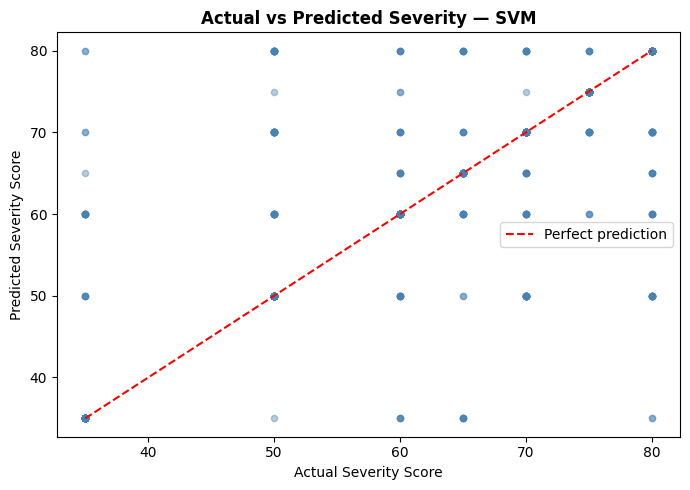

In [23]:
# ── Plot actual vs predicted severity untuk model terbaik ─────────────────
best_name = df_results.iloc[0]['Model']
y_pred_best_severity = np.array([
    get_severity(le.inverse_transform([p])[0]) for p in results[best_name]['y_pred']
])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_severity, y_pred_best_severity, alpha=0.4, s=20, color='steelblue')
mn, mx = min(y_test_severity.min(), y_pred_best_severity.min()), \
         max(y_test_severity.max(), y_pred_best_severity.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Severity Score')
ax.set_ylabel('Predicted Severity Score')
ax.set_title(f'Actual vs Predicted Severity — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/eval_severity_scatter.png', dpi=120)
plt.show()

## 7. Pilih & Export Model Terbaik

In [24]:
# Pilih model berdasarkan F1-score macro tertinggi
best_model_name = df_results.iloc[0]['Model']
best_model      = trained_models[best_model_name]
best_f1         = df_results.iloc[0]['F1-Score (macro)']

print(f'✅ Model terbaik : {best_model_name}')
print(f'   F1-score macro: {best_f1:.4f}')

✅ Model terbaik : SVM
   F1-score macro: 0.6962


In [25]:
# Simpan semua artefak
joblib.dump(best_model, MODELS_PATH / 'best_model.pkl')
joblib.dump(le,         MODELS_PATH / 'label_encoder.pkl')
joblib.dump(scaler,     MODELS_PATH / 'scaler.pkl')

# Simpan konfigurasi feature extractor
feat_config = {
    'img_size'       : list(IMG_SIZE),
    'hog_orientations': 9,
    'hog_pixels_per_cell': [16, 16],
    'hog_cells_per_block': [2, 2],
    'color_hist_bins': 32,
    'feature_dim'    : int(sample_feat.shape[0]),
}
with open(MODELS_PATH / 'feature_extractor_config.json', 'w') as f:
    json.dump(feat_config, f, indent=2)

# Simpan perbandingan model
model_comparison = {}
for name, res in results.items():
    model_comparison[name] = {
        'accuracy' : round(res['accuracy'],  4),
        'precision': round(res['precision'], 4),
        'recall'   : round(res['recall'],    4),
        'f1_macro' : round(res['f1_macro'],  4),
        **{k: round(v, 4) for k, v in regression_results[name].items()},
    }
model_comparison['best_model'] = best_model_name
with open(MODELS_PATH / 'model_comparison.json', 'w') as f:
    json.dump(model_comparison, f, indent=2)

print('File yang tersimpan:')
for p in sorted(MODELS_PATH.iterdir()):
    print(f'  {p.name}')

File yang tersimpan:
  best_model.pkl
  eda_class_distribution.png
  eda_resolution.png
  eda_sample_images.png
  eval_confusion_matrices.png
  eval_model_comparison.png
  eval_severity_scatter.png
  feature_extractor_config.json
  label_encoder.pkl
  model_comparison.json
  scaler.pkl


In [26]:
# ── Verifikasi: uji inference dengan gambar sample ─────────────────────────
loaded_model  = joblib.load(MODELS_PATH / 'best_model.pkl')
loaded_le     = joblib.load(MODELS_PATH / 'label_encoder.pkl')
loaded_scaler = joblib.load(MODELS_PATH / 'scaler.pkl')

sample_path = df_meta['path'].values[0]
feat_raw    = extract_features(sample_path)
feat_scaled = loaded_scaler.transform([feat_raw])
pred_enc    = loaded_model.predict(feat_scaled)[0]
pred_class  = loaded_le.inverse_transform([pred_enc])[0]
probas      = loaded_model.predict_proba(feat_scaled)[0]
confidence  = float(probas.max())
sev_score   = get_severity(pred_class)

inference_result = {
    'predicted_class': pred_class,
    'confidence'     : round(confidence, 4),
    'probabilities'  : {cls: round(float(p), 4)
                        for cls, p in zip(loaded_le.classes_, probas)},
    'model_used'     : best_model_name,
    'severity_score' : sev_score,
    'severity_level' : severity_level(sev_score),
}

print('=== Contoh Output Inference ===')
print(json.dumps(inference_result, indent=2, ensure_ascii=False))

=== Contoh Output Inference ===
{
  "predicted_class": "dark spots",
  "confidence": 0.4504,
  "probabilities": {
    "Redness": 0.0569,
    "dark spots": 0.4504,
    "inflammatory acne": 0.0961,
    "non inflammatory acne black heads": 0.1362,
    "non inflammatory acne white heads": 0.0465,
    "pigmentation": 0.1639,
    "pores": 0.0074,
    "wrinkles": 0.0426
  },
  "model_used": "SVM",
  "severity_score": 70,
  "severity_level": "Severe"
}


## ✅ Pipeline Selesai!

**File yang dihasilkan di folder `models/`:**

| File | Fungsi |
|---|---|
| `best_model.pkl` | Model terbaik untuk inference |
| `label_encoder.pkl` | Encoder label class |
| `scaler.pkl` | StandardScaler untuk normalisasi fitur |
| `feature_extractor_config.json` | Konfigurasi HOG + color histogram |
| `model_comparison.json` | Hasil evaluasi semua model |
| `eda_*.png` | Grafik EDA |
| `eval_*.png` | Grafik evaluasi |

**Langkah selanjutnya:** Salin file `best_model.pkl`, `label_encoder.pkl`, dan `scaler.pkl` ke folder `backend-ml/models/` lalu jalankan FastAPI service.